### <font color="brown">Data Management for Data Science</font>
### <font color="brown">Lab 03: Amazon Product Reviews </font>
### <font color="brown">Due Date : March 13, 2026 11.59PM (see codebench for any updates) </font>
You can still submit 48 hours late. But you will only have 4 total late days for all assignments, max 2 late days per assignment. Additional late days will be penalized.

<div class="alert alert-block alert-info">
<h3>Student Information</h3> Please provide information about yourself.<br>
<b>Name</b>: Ryan Amir<br> 
<b>NetID</b>: Redacted for public portfolio<br>
<b>Recitation #</b>: 10<br>
<b>Notes to Grader</b> (optional):<br>
<br><br>
<b>IMPORTANT</b>
Your work will not be graded withour your initials below<br>
I certify that this lab represents my own work and I have read the RU academic intergrity policies at<br>
<a href="https://studentconduct.rutgers.edu/processes/academic-integrity">https://www.cs.rutgers.edu/academic-integrity/introduction </a><br>
<b>Initials</b>:   RA   (eg: AG for Andy Guna)

## How to Ask Questions
Please post all clarification questions related to the lab to <b>canvas discussion forum</b>. Please email staff for questions specific to your solution. 

## Initialize 
Run the code below to initialize standard packages we use in this lab.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 120)

# Task 1 - Loading and Analyzing Amazon Data (20 points)
Reading and analyzing real datasets is a fundamental skill in data science, essential for uncovering patterns, trends, and insights hidden within the data. The process begins by importing the dataset into a suitable environment, such as Python using libraries like Pandas. Properly loading the data allows for an initial exploration where data types, missing values, and summary statistics are examined. This stage often involves cleaning and preprocessing to handle inconsistencies, such as dealing with null values or standardizing formats. Once the data is in good shape, various analytical techniques, including descriptive statistics, data visualization, and correlation analysis, help identify relationships and trends. Through this structured approach, datasets transform from raw information into actionable knowledge, guiding decisions and deeper analyses.

In this problem, we will read a file of product data from amazon and do some analysis

### Activity 1.1 - Read and Analyze the data file
The data file given at **/srv/shared/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv** contains data file from amazon. Read the file and find out more about the file

In [2]:
import pandas as pd

df = pd.read_csv("/srv/shared/labs/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv")

print(df.shape)
print(df.columns)
print(df.head())

(5000, 24)
Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand', 'categories', 'primaryCategories', 'imageURLs',
       'keys', 'manufacturer', 'manufacturerNumber', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs'],
      dtype='object')
                     id             dateAdded           dateUpdated  \
0  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   
1  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   
2  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   
3  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   
4  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   

                                                name       asins   brand  \
0  Amazon Kindle E-Reader 6" Wifi (8th Generation...  B00Z

### Activity 1.2 - What is in this data file?
Manually inspect the data to see what is included in this data set. Write the answer below in a markdown cell(no code necessary). Explain each column in your own words below. For each feature, indicate how it can be useful or not useful in analysis of Amazon products based on reviews.

This dataset contains Amazon product and review information, where each row appears to represent a review tied to a product. It includes product details such as name, brand, categories, primaryCategories, asins, manufacturer, and manufacturerNumber, along with metadata like id, keys, imageURLs, sourceURLs, dateAdded, and dateUpdated. It also includes review-specific fields such as reviews.date, reviews.title, reviews.text, reviews.rating, reviews.numHelpful, reviews.username, and recommendation fields like reviews.doRecommend or reviews.recommend. For analysis of Amazon products based on reviews, the most useful columns are the product identifiers and categories, along with reviews.rating, reviews.text, reviews.title, and reviews.numHelpful, because they help measure customer satisfaction, compare products, and study review trends. The metadata and URL fields are less useful for analysis but can still help with tracking and organization.

### Activity 1.3 - Check for Missing Data
Are there missing data? Finding missing data values in a dataset is crucial because they can significantly impact the quality and accuracy of data analysis. missing values can distort statistical calculations, lead to biased results, and affect the performance of machine learning models. Understanding where and why data is missing helps in deciding how to handle these gaps effectively, whether by imputing values, removing incomplete entries, or using algorithms that can manage missing data. Addressing missing values ensures the analysis remains reliable and that conclusions drawn from the data are well-founded, preventing misleading insights and incorrect decisions. 

Write code to check for missing values in each column and **state the percentage** of missing values for each of the columns. Remove all missing or inconsistemnt data and create a new datafarme <b>df_cleaned</b>. You can use the smaller test samples with 10 and 20 rows, <b>Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_10.csv</b> and <b>Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_20.csv</b> to check if your algorithm is correct.

In [3]:
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

print("Missing values per column:")
print(missing_counts)

print("\nPercentage of missing values per column:")
print(missing_percent)

df_cleaned = df.drop(columns=["reviews.id", "reviews.dateAdded"])
df_cleaned = df_cleaned.dropna()

print("\nOriginal shape:", df.shape)
print("Cleaned shape:", df_cleaned.shape)

Missing values per column:
id                        0
dateAdded                 0
dateUpdated               0
name                      0
asins                     0
brand                     0
categories                0
primaryCategories         0
imageURLs                 0
keys                      0
manufacturer              0
manufacturerNumber        0
reviews.date              0
reviews.dateAdded      3948
reviews.dateSeen          0
reviews.doRecommend       0
reviews.id             4971
reviews.numHelpful        0
reviews.rating            0
reviews.sourceURLs        0
reviews.text              0
reviews.title            13
reviews.username          1
sourceURLs                0
dtype: int64

Percentage of missing values per column:
id                      0.00
dateAdded               0.00
dateUpdated             0.00
name                    0.00
asins                   0.00
brand                   0.00
categories              0.00
primaryCategories       0.00
imageURLs     

### Activity 1.4 - Check for Outliers 
Data outliers are values in a dataset that deviate significantly from the rest of the data points. They are unusually high or low values that do not fit the expected pattern or distribution, often caused by variability in the data, measurement errors, or experimental anomalies. Detecting and addressing outliers is important because they can skew statistical analyses, distort model predictions, and lead to misleading conclusions if not properly handled.

Write the coee to find them (if any), list them and remove them from the data set. If no change, just state so. Try the same with test data files with 10 and 20 observations. 

In [4]:
# your code
# check numeric columns for outliers using IQR
numeric_cols = df_cleaned.select_dtypes(include=["int64", "float64"]).columns

outliers_found = False

for col in numeric_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[col] < lower) | (df_cleaned[col] > upper)]

    print(f"\nOutliers in {col}:")
    print(outliers[[col]])

    if len(outliers) > 0:
        outliers_found = True
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower) & (df_cleaned[col] <= upper)]

if not outliers_found:
    print("No outliers found.")
    
print("\nShape after outlier removal:", df_cleaned.shape)



Outliers in reviews.numHelpful:
      reviews.numHelpful
3                      3
10                     3
20                     1
21                     4
29                     2
...                  ...
4966                   1
4969                   1
4974                   1
4996                   1
4997                   8

[340 rows x 1 columns]

Outliers in reviews.rating:
      reviews.rating
80                 2
93                 2
143                2
229                2
355                2
...              ...
4752               1
4823               1
4904               2
4953               1
4971               2

[85 rows x 1 columns]

Shape after outlier removal: (4561, 22)


# Task 2 Data Cleaning and Feature Engineering
In this activity, you will prepare the dataset for analysis by cleaning and transforming key variables. First, you will convert the relevant date columns into proper datetime format so they can be used for time-based analysis. Next, you will convert numeric columns, such as ratings and helpful votes, into appropriate numeric types to ensure accurate calculations. You will then create a new variable called review_length to measure the length of each review’s text. Finally, you will generate a monthly time bucket from the review date to enable aggregation and trend analysis over time. We need to do the following.

- Convert date columns
- Convert numeric columns
- Create review_length
- Create monthly time bucket

## Data Conversion
Converting date and time data into a standard datetime format ensures consistency, allowing accurate sorting, filtering, time-based grouping, and calculations such as differences between dates. Without standardization, analyses like trend detection, time-series modeling, and monthly or yearly aggregations can produce incorrect or misleading results due to inconsistent formats.

### Actvity 2.1 Convert Data-Time Columns
Find all columns with datetime formats (manually) an convert all data-time columns to datatime objects

In [5]:
date_cols = ["dateAdded", "dateUpdated", "reviews.date", "reviews.dateSeen"]

for col in date_cols:
    df_cleaned[col] = pd.to_datetime(df_cleaned[col], format="ISO8601", errors="coerce")

print(df_cleaned[date_cols].dtypes)

dateAdded           datetime64[ns, UTC]
dateUpdated         datetime64[ns, UTC]
reviews.date        datetime64[ns, UTC]
reviews.dateSeen    datetime64[ns, UTC]
dtype: object


### Actvity 2.2 Convert Numeric Columns
Converting numeric columns to proper numeric data types (such as int or float) ensures that mathematical operations like sums, averages, and comparisons work correctly. If numbers are stored as text (object type), calculations may fail or produce incorrect results, and performance will be significantly slower.

In [6]:
# convert all numeric columns to numeric type
numeric_cols = ["reviews.rating", "reviews.numHelpful"]

for col in numeric_cols:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors="coerce")

print(df_cleaned[numeric_cols].dtypes)

reviews.rating        int64
reviews.numHelpful    int64
dtype: object


## Feature Engineering
Feature engineering is important because it transforms raw data into meaningful variables that better capture patterns and relationships in the dataset. Well-designed features improve model accuracy, interpretability, and overall predictive performance by providing algorithms with more informative inputs.

### Actvity 2.3 Create New Review Lengths Bucket 
Creating a review_length column is important because it quantifies the amount of information in each review, which can help detect patterns such as whether longer reviews tend to have higher or lower ratings. It also enables deeper analysis and modeling, as text length can serve as a useful feature in sentiment analysis, engagement studies, or predictive models.

In [7]:
# Add a new length column to reviews.
df_cleaned["review_length"] = df_cleaned["reviews.text"].str.len()

print(df_cleaned[["reviews.text", "review_length"]].head())

                                        reviews.text  review_length
0  I thought it would be as big as small paper bu...            211
1  This kindle is light and easy to use especiall...             63
2  Didnt know how much i'd use a kindle so went f...            107
4  Solid entry level Kindle. Great for kids. Gift...            176
5  This make an excellent ebook reader. Don't exp...            158


### Actvity 2.4 Create New Monthly Time Bucket
Creating a review_year_month column is important because it allows you to group and analyze reviews by consistent monthly time buckets (e.g., 2026-02), making trend analysis and time-series visualization easier. It also helps reduce date granularity, enabling cleaner aggregation such as counting reviews per month or computing average ratings over time.

In [8]:
# create a new column review_year_month
df_cleaned["review_year_month"] = df_cleaned["reviews.date"].dt.strftime("%Y-%m")

print(df_cleaned[["reviews.date", "review_year_month"]].head())

               reviews.date review_year_month
0 2017-09-03 00:00:00+00:00           2017-09
1 2017-06-06 00:00:00+00:00           2017-06
2 2018-04-20 00:00:00+00:00           2018-04
4 2018-04-24 00:00:00+00:00           2018-04
5 2016-12-14 00:00:00+00:00           2016-12


# Task 3 Product Performance
How does a particular product perform? Analyzing product performance is important because it helps identify which products generate the highest revenue, receive the best ratings, or drive the most engagement. This insight supports better business decisions such as inventory planning, marketing focus, pricing strategy, and product improvement.

### Activity 3.1 Higest Average Ratings
Find the top 10 Product with the highest average ratings. Print the product and average ratings from highest to lowest in a formatted table.

In [9]:
# your code 
top10_avg_ratings = (
    df_cleaned.groupby("name")["reviews.rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top10_avg_ratings.columns = ["Product", "Average Rating"]
print(top10_avg_ratings)


                                             Product  Average Rating
0  Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Black        5.000000
1  Amazon Fire TV with 4K Ultra HD and Alexa Voic...        5.000000
2  Kindle Oasis E-reader with Leather Charging Co...        4.869565
3  Amazon 9W PowerFast Official OEM USB Charger a...        4.842105
4        Amazon - Echo Plus w/ Built-In Hub - Silver        4.797891
5          Amazon - Kindle Voyage - 6" - 4GB - Black        4.745098
6  Kindle Oasis E-reader with Leather Charging Co...        4.727273
7  Amazon Echo Show Alexa-enabled Bluetooth Speak...        4.717662
8  Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...        4.686869
9  All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi...        4.680000


### Activity 3.2  Visualize Product and Average Ratings 
Select the proper visualization and Plot the top 10 products by average rating. 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
plt.barh(top10_avg_ratings["Product"][::-1], top10_avg_ratings["Average Rating"][::-1])
plt.xlabel("Average Rating")
plt.ylabel("Product Name")
plt.title("Top 10 Products by Average Rating")
plt.xlim(0, 5.2)
plt.tight_layout()
plt.show()

### Activity 3.3  Products with Most Reviews
Which product(s) receive the most reviews? Find the top 10 products with the most reviews.


In [11]:
top10_most_reviews = (
    df_cleaned.groupby("name")["reviews.rating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top10_most_reviews.columns = ["Product", "Number of Reviews"]
print(top10_most_reviews)

                                             Product  Number of Reviews
0  Amazon Echo Show Alexa-enabled Bluetooth Speak...                804
1  All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi...                763
2        Amazon - Echo Plus w/ Built-In Hub - Silver                569
3  Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...                526
4  Brand New Amazon Kindle Fire 16gb 7" Ips Displ...                415
5  Fire Tablet, 7 Display, Wi-Fi, 16 GB - Include...                322
6  Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...                207
7  Amazon Tap - Alexa-Enabled Portable Bluetooth ...                194
8  Kindle E-reader - White, 6 Glare-Free Touchscr...                145
9  Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...                 99


### Activity 3.4  Plot Highest Reviews vs Average Ratings?
For the top 25 products with highest reviews, plot reviews vs ratings. Do highly reviewed products also have high ratings? What is a good plot to communicate this?

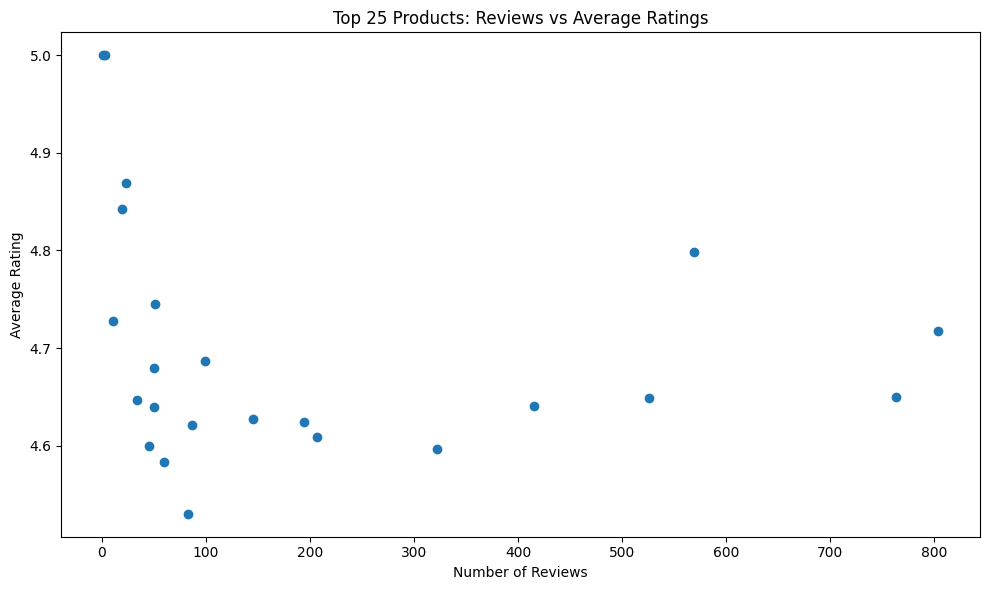

In [12]:
top25_reviews_vs_ratings = (
    df_cleaned.groupby("name")
    .agg(
        Number_of_Reviews=("reviews.rating", "count"),
        Average_Rating=("reviews.rating", "mean")
    )
    .sort_values("Number_of_Reviews", ascending=False)
    .head(25)
    .reset_index()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(top25_reviews_vs_ratings["Number_of_Reviews"],
            top25_reviews_vs_ratings["Average_Rating"])
plt.xlabel("Number of Reviews")
plt.ylabel("Average Rating")
plt.title("Top 25 Products: Reviews vs Average Ratings")
plt.tight_layout()
plt.show()

# A scatter plot works well here because it makes it easy to see how the number of reviews compares to the average rating for 
# the top 25 products. From the plot, it looks like products with more reviews do not always have the highest ratings, 
# but most of them still have fairly good ratings overall.

# Task 4 Brand-Level Insights

### 4.1 Brand Index

<div style="font-family: Arial, sans-serif; line-height: 1.5;">
  <p>
    We'd like to create a <b>Combined Brand Performance Index (CBPI)</b> for each brand based on:
    <b>Avg Rating</b>, <b>Total Reviews</b>, and <b>% Recommended</b>.
    Since these metrics are on different scales, we first <b>normalize</b> each one using <b>min-max scaling</b>.
  </p>

  <p>
    <b>Min-Max Normalization:</b><br>
    <code>Norm(X) = (X - X_min) / (X_max - X_min)</code>
  </p>

  <p>
    After normalization, compute a weighted index for each brand:
  </p>

  <p>
    <b>
      CBPI<sub>brand</sub> = w1 (Norm Avg Rating) + w2 (Norm Total Reviews) + w3 (Norm % Recommended),
      where w1 + w2 + w3 = 1
    </b>
  </p>

  <p>
    Use the following weights:
    <b>CBPI = 0.5 (Rating) + 0.2 (Reviews) + 0.3 (Recommendation)</b>
  </p>
</div>



In [26]:
product_stats = (
    df_cleaned.groupby("name")
    .agg(
        avg_rating=("reviews.rating", "mean"),
        total_reviews=("reviews.rating", "count"),
        pct_recommended=("reviews.doRecommend", "mean")
    )
    .dropna()
    .reset_index()
)

# convert recommendation rate to percentage
product_stats["pct_recommended"] = product_stats["pct_recommended"] * 100

# safe min-max normalization
def min_max_safe(series):
    if series.max() == series.min():
        return pd.Series([1.0] * len(series), index=series.index)
    return (series - series.min()) / (series.max() - series.min())

product_stats["norm_avg_rating"] = min_max_safe(product_stats["avg_rating"])
product_stats["norm_total_reviews"] = min_max_safe(product_stats["total_reviews"])
product_stats["norm_pct_recommended"] = min_max_safe(product_stats["pct_recommended"])

# compute product index using given weights
product_stats["CPI"] = (
    0.5 * product_stats["norm_avg_rating"] +
    0.2 * product_stats["norm_total_reviews"] +
    0.3 * product_stats["norm_pct_recommended"]
)

# show top 10 products
top10_product_index = (
    product_stats[["name", "avg_rating", "total_reviews", "pct_recommended", "CPI"]]
    .sort_values("CPI", ascending=False)
    .head(10)
)

print(top10_product_index)

                                                 name  avg_rating  total_reviews  pct_recommended       CPI
10  Amazon Fire TV with 4K Ultra HD and Alexa Voic...    5.000000              3       100.000000  0.800498
6   Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Black    5.000000              1       100.000000  0.800000
5         Amazon - Echo Plus w/ Built-In Hub - Silver    4.797891            569        99.121265  0.691655
9   Amazon Echo Show Alexa-enabled Bluetooth Speak...    4.717662            804        97.388060  0.596273
2   All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi...    4.650066            763        97.378768  0.513764
22  Kindle Oasis E-reader with Leather Charging Co...    4.727273             11       100.000000  0.512281
21  Kindle Oasis E-reader with Leather Charging Co...    4.869565             23        95.652174  0.494747
16  Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...    4.648289            526        97.718631  0.466285
4   All-New Fire HD 8 Tablet

### 4.2 Visualize with a Bubble Plot


<p>
A <strong>bubble plot</strong> is especially powerful for analyzing Amazon reviews because it allows you to visualize 
<strong>three quantitative variables at once</strong>.
</p>

<ul>
  <li><strong>X-axis</strong> &rarr; One numeric variable</li>
  <li><strong>Y-axis</strong> &rarr; Another numeric variable</li>
  <li><strong>Bubble Size</strong> &rarr; Magnitude of a third numeric variable</li>
  <li><strong>(Optional) Color</strong> &rarr; Category such as brand or product type</li>
</ul>

Make a bubble plot using Month (x-axis), Average Rating (y-axis) and Bubble size is the number of reviews for the product for that month.


In [ ]:
import matplotlib.pyplot as plt

monthly_stats = df_cleaned.copy()

monthly_stats["reviews.date"] = pd.to_datetime(monthly_stats["reviews.date"], errors="coerce")
monthly_stats = monthly_stats.dropna(subset=["reviews.date"])

monthly_stats["review_year_month"] = (
    monthly_stats["reviews.date"]
    .dt.tz_localize(None)
    .dt.to_period("M")
    .astype(str)
)

monthly_stats = (
    monthly_stats.groupby("review_year_month")
    .agg(
        avg_rating=("reviews.rating", "mean"),
        review_count=("reviews.rating", "count")
    )
    .reset_index()
)

plt.figure(figsize=(14, 6))
plt.scatter(
    monthly_stats["review_year_month"],
    monthly_stats["avg_rating"],
    s=monthly_stats["review_count"] * 8,
    alpha=0.6,
    edgecolors="black",
    linewidths=0.5
)

plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.title("Monthly Average Rating with Bubble Size by Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.3 Helpful Comments vs Average Ratings by Brand

<p>Do a <strong>bubble plot</strong> to show multiple brand-level metrics in one view:</p>

<ul>
  <li><strong>X-axis</strong> &rarr; Average Rating</li>
  <li><strong>Y-axis</strong> &rarr; Total Helpful Votes (or Avg Helpful Votes)</li>
  <li><strong>Bubble Size</strong> &rarr; Total Reviews</li>
  <li><strong>Color</strong> &rarr; Brand Category <em>(optional)</em></li>
</ul>



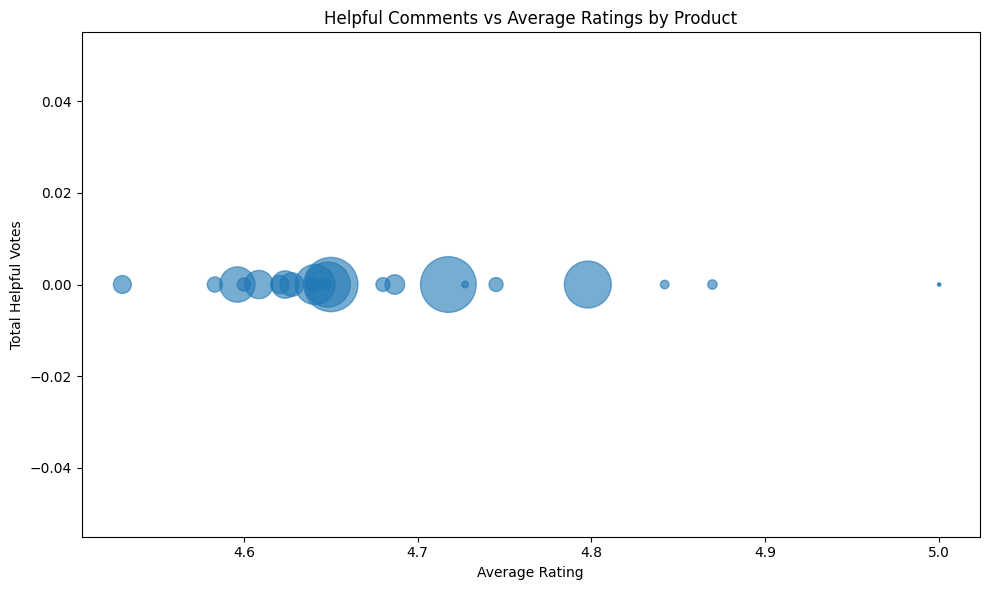

In [24]:
import matplotlib.pyplot as plt

product_helpful_stats = (
    df_cleaned.groupby("name")
    .agg(
        avg_rating=("reviews.rating", "mean"),
        total_helpful_votes=("reviews.numHelpful", "sum"),
        total_reviews=("reviews.rating", "count")
    )
    .dropna()
    .reset_index()
)

plt.figure(figsize=(10, 6))
plt.scatter(
    product_helpful_stats["avg_rating"],
    product_helpful_stats["total_helpful_votes"],
    s=product_helpful_stats["total_reviews"] * 2,
    alpha=0.6
)

plt.xlabel("Average Rating")
plt.ylabel("Total Helpful Votes")
plt.title("Helpful Comments vs Average Ratings by Product")
plt.tight_layout()
plt.show()

# Task 5 - Predicting Product Recommendations from Reviews


<p>
A useful question we can explore with this Amazon reviews dataset is:
<strong>Can we predict whether a review will recommend the product?</strong>
</p>

<p>
This becomes a <strong>binary classification</strong> problem, where the goal is to learn a model that predicts
whether a review is a recommendation (<code>True</code>) or not (<code>False</code>).
</p>

<h4>Target (What We Want to Predict) : <code>reviews.doRecommend</code></h4>


<h4>Features X (Inputs to the Model)</h4>
<p>Build predictive features from the review and product metadata, such as:</p>
<ul>
  <li><strong>Rating</strong> (<code>reviews.rating</code>) &mdash; higher ratings often correspond to recommendations.</li>
  <li><strong>Text length</strong> (<code>review_length</code>) &mdash; computed from <code>reviews.text</code> (e.g., number of characters or words).</li>
  <li><strong>Brand</strong> (<code>brand</code>) &mdash; some brands may have consistently higher or lower recommendation rates.</li>
  <li><strong>Category</strong> (<code>categories</code> or <code>primaryCategories</code>) &mdash; recommendation behavior may differ across product types.</li>
</ul>

<h4>What This Analysis will Tell Us</h4>
<ul>
  <li>Which factors most strongly influence recommendations (rating vs text features vs brand/category).</li>
  <li>Whether recommendations can be predicted reliably, even when ratings are missing or noisy.</li>
  <li>Which brands or categories tend to generate more “recommended” outcomes, after controlling for rating.</li>
</ul>



### 5.1 Load the Original Data and make a copy with only the columns we need.

In [25]:
# code here
import pandas as pd

# load dataset
df = pd.read_csv("/srv/shared/labs/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv")

# keep only useful columns
cols = [
    "reviews.doRecommend",
    "reviews.rating",
    "reviews.text",
    "brand",
    "categories",
    "primaryCategories"
]

reviews_df = df[cols].copy()
reviews_df.head()

,reviews.doRecommend,reviews.rating,reviews.text,brand,categories,primaryCategories
0,False,3,I thought it would be as big as small paper bu...,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics
1,True,5,This kindle is light and easy to use especiall...,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics
2,True,4,Didnt know how much i'd use a kindle so went f...,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics
3,True,5,I am 100 happy with my purchase. I caught it o...,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics
4,True,5,Solid entry level Kindle. Great for kids. Gift...,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics


### 5.2 Clean the target 
Check to make sure target variable is binary

In [3]:
# code
# check before cleaning
print(reviews_df["reviews.doRecommend"].value_counts(dropna=False))

# remove missing values 
reviews_df = reviews_df.dropna(subset=["reviews.doRecommend"]).copy()

# convert True/False to 1/0
reviews_df["reviews.doRecommend"] = reviews_df["reviews.doRecommend"].astype(int)

# check after cleaning
print(reviews_df["reviews.doRecommend"].value_counts(dropna=False))

reviews.doRecommend
True     4765
False     235
Name: count, dtype: int64
reviews.doRecommend
1    4765
0     235
Name: count, dtype: int64


### 5.3 Create the features (X)
ratings and text length has to be numeric.

In [29]:
# code
# fill missing values
reviews_df["reviews.text"] = reviews_df["reviews.text"].fillna("")
reviews_df["brand"] = reviews_df["brand"].fillna("Unknown")
reviews_df["primaryCategories"] = reviews_df["primaryCategories"].fillna("Unknown")

# create text length
reviews_df["review_length"] = reviews_df["reviews.text"].str.len()

# define features and target
X = reviews_df[["reviews.rating", "review_length", "brand", "primaryCategories"]]
y = reviews_df["reviews.doRecommend"]

X.head()



,reviews.rating,review_length,brand,primaryCategories
0,3,211,Amazon,Electronics
1,5,63,Amazon,Electronics
2,4,107,Amazon,Electronics
3,5,757,Amazon,Electronics
4,5,176,Amazon,Electronics


### 5.4 Split into Training and Test Sets
We will use the Training data to learn the model and testing data to see if the model actually works. Split the data into X_train, X_test, y_train, y_test sets. You can use 80% of the data for the training set.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4000, 4)
X_test shape: (1000, 4)
y_train shape: (4000,)
y_test shape: (1000,)


### 5.5 Setting Up a Binary Classification Pipeline

Because we have numbers + categories, we’ll: scale/keep numeric columns and one-hot encode categorical columns. We can set up a binary classification pipeline to deal with number of steps in the process of setting things up.

<h4>ColumnTransformer</h4>
<p>
<code>ColumnTransformer</code> lets you apply
<strong>different preprocessing steps to different columns at the same time</strong>.
</p>

<h4>OneHotEncoder</h4>
<p>
Machine learning models need numbers, but many datasets contain categorical values like
<code>"red"</code>, <code>"green"</code>, and <code>"blue"</code>. <code>OneHotEncoder</code> converts each category into
a numeric format by creating <strong>new columns</strong>:
</p>

<h4>Pipeline</h4>
<p>
A <code>Pipeline</code> chains together multiple steps (like cleaning, encoding, and modeling)
into one organized workflow. This helps you:
</p>
<ul>
  <li>Keep code clean and easy to follow</li>
  <li>Avoid mistakes like data leakage (accidentally using test info during training)</li>
  <li>Train and evaluate using the exact same steps every time</li>
</ul>


<h4>SimpleImputer</h4>
<p>
Real datasets often contain missing values (like <code>NaN</code>).
<code>SimpleImputer</code> fills in missing values using a strategy such as:<strong>Mean</strong> (average), <strong>Median</strong> (middle value),<strong>Most frequent</strong> (mode)
</p>

<h4>LogisticRegression</h4>
<p>
<code>LogisticRegression</code> is one of the most common and reliable
<strong>classification</strong> algorithms. Even though it has “regression” in the name, it’s used to predict
categories like: <code>recommend</code> vs <code>not recommend</code>, <code>spam</code> vs <code>not spam</code>
</p>




In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# choose numeric and categorical columns
numeric_features = ["reviews.rating", "review_length"]
categorical_features = ["brand", "primaryCategories"]

# preprocessing for numeric columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# combine preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# full pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['reviews.rating',
                                                   'review_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore')

### 5.6 Train the model
Use the training data, X_train and y_train to fit the model. Use the <code>model.fit</code>

In [ ]:
# code
model.fit(X_train, y_train)


### 5.7 Evaluate it with accuracy + confusion matrix

<p><b>Accuracy</b> is the simplest performance metric for a classification model: it measures the fraction of predictions the model got correct overall, i.e., (correct predictions) ÷ (total predictions). However, accuracy can be misleading when classes are imbalanced (for example, if 95% of examples are “negative,” a model that always predicts “negative” can look “accurate” but be useless).<br>
    
<b>F1-score</b> helps in these cases because it balances <i>precision</i> (how many predicted positives are truly positive) and <i>recall</i> (how many true positives were found) using their harmonic mean, so it rewards models that do well on both. <br>
    
A <b>confusion matrix</b> gives a complete breakdown of results by counting <i>true positives</i>, <i>false positives</i>, <i>true negatives</i>, and <i>false negatives</i>, making it easy to see what kinds of mistakes the model is making and to compute metrics like accuracy, precision, recall, and F1.</p>


In [9]:
# code 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# make predictions
y_pred = model.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# optional extra detail
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.973

Confusion Matrix:
[[ 23  24]
 [  3 950]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.49      0.63        47
           1       0.98      1.00      0.99       953

    accuracy                           0.97      1000
   macro avg       0.93      0.74      0.81      1000
weighted avg       0.97      0.97      0.97      1000



### 5.8 Your Observations
What do you observe. Write the report below.

The model was able to predict recommendations fairly well. Based on the confusion matrix, most of the predictions were correct, but there were still some cases where the model confused recommended and not recommended reviews. One thing I noticed is that the data has a lot more positive recommendations than negative ones, which can make the model biased toward predicting recommendations more often.


### Submission Instructions
Rename the lab as netID_Lab03.ipynb and submit to codebench. (eg: adg133_Lab03.ipynb)